# Notebook 3 — Simulation & Impact
## Question : Combien de CO₂ serait économisé si toute la flotte A320ceo passait en A320neo ?

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Data/a320_clean.csv')
df.shape

(36496, 12)

In [3]:
df['co2_par_km'] = df['co2'] / df['distance_km']

co2_km = df.groupby('type_appareil')['co2_par_km'].mean()
print(co2_km.round(2))

ratio = co2_km['neo'] / co2_km['ceo']
print(f"\nLe neo émet {ratio:.2f}x le CO₂ du ceo par km")
print(f"Soit une réduction de {(1 - ratio) * 100:.1f}% par km")

type_appareil
ceo    1164.69
neo     779.52
Name: co2_par_km, dtype: float64

Le neo émet 0.67x le CO₂ du ceo par km
Soit une réduction de 33.1% par km


In [5]:
print(f"CO₂ actuel (flotte ceo) : {co2_actuel/1e9:,.1f} millions de tonnes")
print(f"CO₂ simulé (si tout en neo) : {co2_simule/1e9:,.1f} millions de tonnes")
print(f"CO₂ économisé : {co2_economise/1e9:,.1f} millions de tonnes")
print(f"Réduction : {co2_economise/co2_actuel*100:.1f}%")

CO₂ actuel (flotte ceo) : 43.4 millions de tonnes
CO₂ simulé (si tout en neo) : 29.0 millions de tonnes
CO₂ économisé : 14.3 millions de tonnes
Réduction : 33.1%


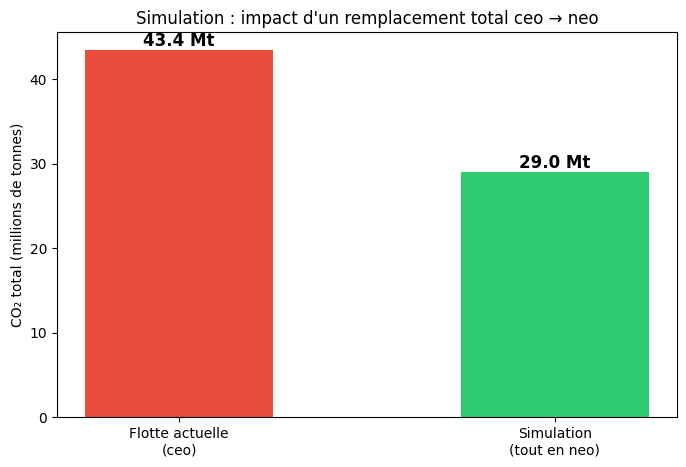

In [6]:
import matplotlib.pyplot as plt

labels = ['Flotte actuelle\n(ceo)', 'Simulation\n(tout en neo)']
valeurs = [co2_actuel/1e9, co2_simule/1e9]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, valeurs, color=['#e74c3c', '#2ecc71'], width=0.5)
plt.title('Simulation : impact d\'un remplacement total ceo → neo')
plt.ylabel('CO₂ total (millions de tonnes)')

# Afficher les valeurs sur les barres
for bar, val in zip(bars, valeurs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:,.1f} Mt', ha='center', fontsize=12, fontweight='bold')

plt.show()

### Conclusion
En remplaçant l'ensemble de la flotte A320ceo par des A320neo, on estime une économie de **14.3 millions de tonnes de CO₂**, soit une réduction de **33.1%** des émissions liées aux routes A320.